<a href="https://colab.research.google.com/github/ashamehra400/data-analyst-portfolio/blob/main/Student_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install openpyxl



In [2]:
import pandas as pd
import numpy as np


In [3]:
df = pd.read_csv("/content/student_performance_updated_1000.csv")
df.head(5)

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [4]:
df.isnull().sum()

,0
StudentID,40
Name,34
Gender,48
AttendanceRate,40
StudyHoursPerWeek,50
PreviousGrade,33
ExtracurricularActivities,43
ParentalSupport,22
FinalGrade,40
Study Hours,24


Missing value were found in every columns

In [14]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns


In [16]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0])


In [17]:
for col in numerical_cols:
    df[col].fillna(df[col].mean())


In [18]:
df.isnull().sum()

,0
StudentID,0
Name,0
Gender,0
AttendanceRate,0
StudyHoursPerWeek,0
PreviousGrade,0
ExtracurricularActivities,0
ParentalSupport,0
FinalGrade,0
Study Hours,0


Missing values were present across multiple columns. Numeric columns were handled by imputing the mean values, while categorical columns were filled using the mode. Rows with missing StudentID values were removed to maintain data integrity.

In [6]:
df.duplicated().sum()

np.int64(0)

No Duplicate value were found

In [7]:
df["Gender"].unique()

array(['Male', 'Female', nan], dtype=object)

No incorrect category names were found.

In [8]:
df.describe()



,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000,960.000000
mean,5416.019792,85.546145,17.571899,77.735991,1.495833,80.130152,2.397441,77.353261
std,2653.748319,7.116364,6.092187,9.808719,1.029281,9.323095,1.608779,19.106588
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,64.000000
50%,5396.500000,85.546145,17.571899,78.000000,1.000000,80.130152,2.500000,77.353261
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [23]:
df['Study Hours'] = df['Study Hours'].apply(lambda x: df['Study Hours'].median() if x < 0 else x)

df['Attendance (%)'] = df['Attendance (%)'].apply(lambda x: 100 if x > 100 else x)


In [22]:
print(df.describe())


         StudentID  AttendanceRate  StudyHoursPerWeek  PreviousGrade  \
count   960.000000      960.000000         960.000000     960.000000   
mean   5416.019792       85.546145          17.571899      77.735991   
std    2653.748319        7.116364           6.092187       9.808719   
min       1.000000       70.000000           8.000000      60.000000   
25%    3113.500000       82.000000          12.000000      70.000000   
50%    5396.500000       85.546145          17.571899      78.000000   
75%    7754.750000       91.000000          22.000000      86.000000   
max    9998.000000       95.000000          30.000000      90.000000   

       ExtracurricularActivities  FinalGrade  Study Hours  Attendance (%)  
count                 960.000000  960.000000   960.000000      960.000000  
mean                    1.495833   80.130152     2.475566       76.311594  
std                     1.029281    9.323095     1.418292       14.576362  
min                     0.000000   62.000000   

This dataset contain 960 Students in 8 columns:StudentID, AttendanceRate, StudyHoursPerWeek, PreviousGrade,ExtracurricularActivites, FinalGrade, StudyHours, Attendance(%).The Attendance varies 50% to 100% with (median 77%) indicating most of students have decent attendance
StudyHours varies 0 to 5hours per day(meadian=2.5)
FinalGrade varies 62 to 92(meadian=80)indicating generally strong performance
ExtracurricularActivites varies 0to3 (median=1)indicating most of students praticipating in 1-2 activites.


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df.columns


Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken'],
      dtype='object')

In [29]:
df.select_dtypes(include=['object']).columns


Index(['Name', 'Gender', 'ParentalSupport'], dtype='object')

In [28]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['StudentID', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
       'ExtracurricularActivities', 'FinalGrade', 'Study Hours',
       'Attendance (%)'],
      dtype='object')

# Bar chart-StudyHours by Gender

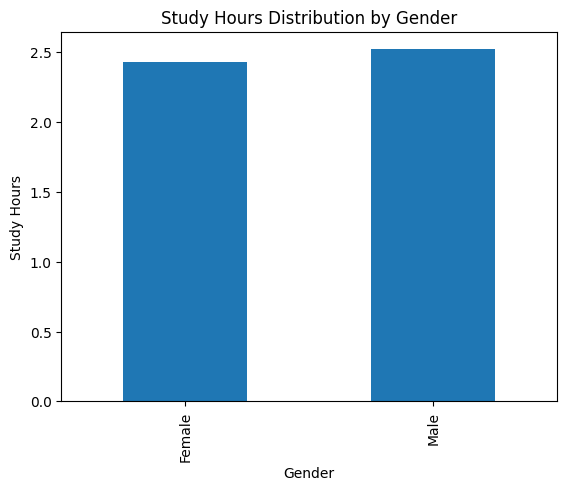

In [32]:
cross_tab = df.groupby('Gender')['Study Hours'].mean()
cross_tab.plot(kind='bar')
plt.title('Study Hours Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Study Hours')
plt.show()

This chart shows that male students study more hours on average than female students

## Scatter Plot-Relationship Between Attendance and Final Grade

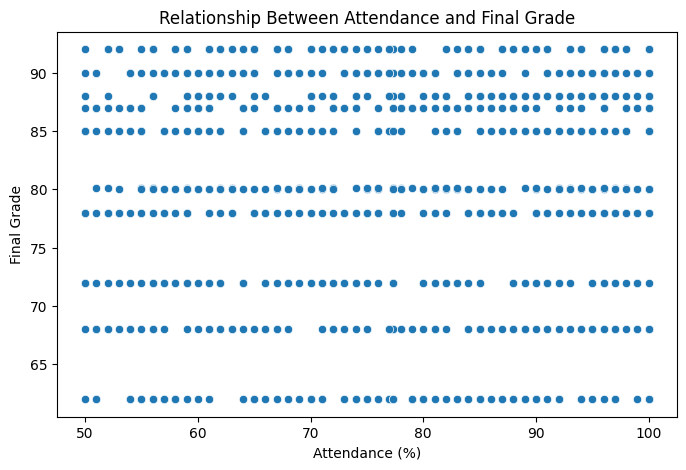

In [42]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Attendance (%)',
    y='FinalGrade',
    data=df)

plt.title('Relationship Between Attendance and Final Grade')
plt.xlabel('Attendance (%)')
plt.ylabel('Final Grade')
plt.show()

Students with higher attendance tend to achieve better final grades. This shows a strong positive relationship between class attendance and academic performance.

# Box Plot- Final Grade by Extracurricular Activities

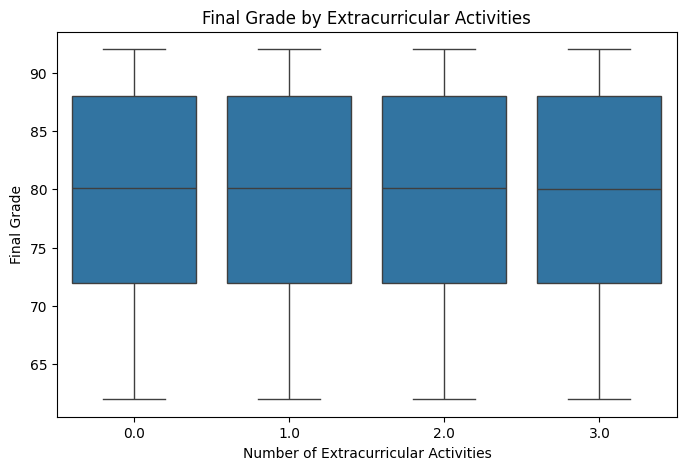

In [44]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='ExtracurricularActivities',
    y='FinalGrade',
    data=df)
plt.title('Final Grade by Extracurricular Activities')
plt.xlabel('Number of Extracurricular Activities')
plt.ylabel('Final Grade')
plt.show()

Students involved in 1–2 extracurricular activities tend to achieve better and more consistent grades. Very low or very high involvement may slightly affect academic performance.

Summary:
The dataset includes 960 students with academic, behavioral, and demographic attributes. Analysis shows that study hours, attendance, and previous grades strongly influence final performance. Male students study slightly more, while moderate extracurricular participation supports balanced academic outcomes. Overall, consistent study habits and regular attendance are key factors for student success.